In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('titanic.csv')

print("Shape:", df.shape)
df.head() 

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [3]:
# Overall survival rate
print("Survival rate:")
print(df['Survived'].value_counts())
print(f"\n{df['Survived'].mean()*100:.1f}% of passengers survived")

Survival rate:
Survived
0    549
1    342
Name: count, dtype: int64

38.4% of passengers survived


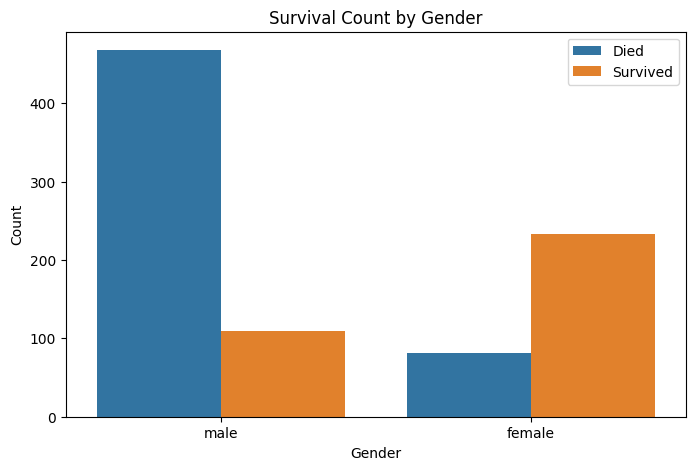

In [4]:
# Chart 1: Survival by Gender
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Died', 'Survived'])
plt.show()

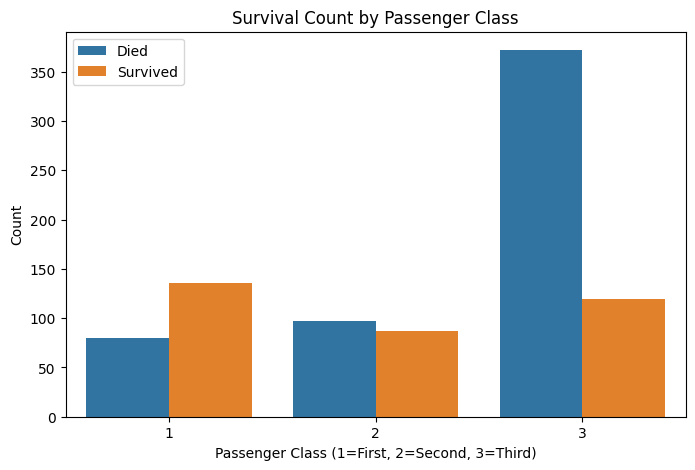

In [5]:
# Chart 2: Survival by Passenger Class
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Count')
plt.legend(['Died', 'Survived'])
plt.show()

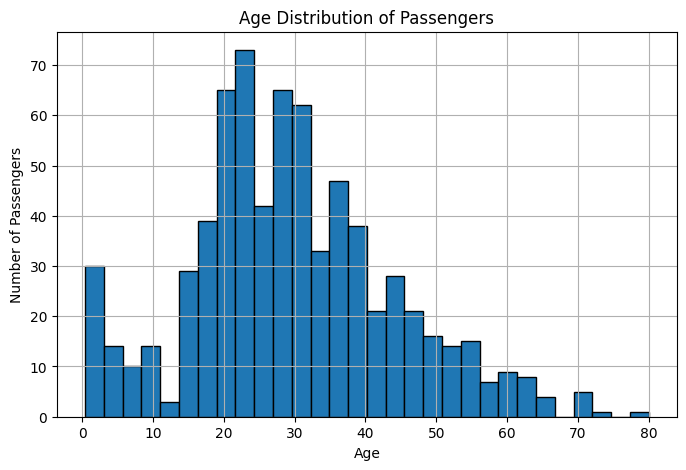

In [6]:
# Chart 3: Age distribution
plt.figure(figsize=(8, 5))
df['Age'].hist(bins=30, edgecolor='black')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

In [7]:
# Clean the data for ML

# 1. Fill missing Age with median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# 2. Drop Cabin column (too many missing values - 687!)
df.drop(columns=['Cabin'], inplace=True)

# 3. Fill missing Embarked with most common value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# 4. Convert Sex to numbers (male=0, female=1)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# 5. Convert Embarked to numbers
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 6. Drop columns ML doesn't need
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

# Confirm no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nData shape:", df.shape)
print("\nFirst 3 rows after cleaning:")
df.head(3)

Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Data shape: (891, 8)

First 3 rows after cleaning:


C:\Users\Sree Lakshmi Chowdam\AppData\Local\Temp\ipykernel_8660\1509613069.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\Sree Lakshmi Chowdam\AppData\Local\Temp\ipykernel_8660\1509613069.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Separate features (X) and target (y)
X = df.drop('Survived', axis=1)  # everything except Survived
y = df['Survived']                # what we want to predict

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 712
Testing samples: 179


In [9]:
# Train 3 models and compare

# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))

# Model 2: Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))

# Model 3: Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

# Compare results
print("Model Accuracy Comparison:")
print(f"Logistic Regression : {lr_acc*100:.2f}%")
print(f"Decision Tree       : {dt_acc*100:.2f}%")
print(f"Random Forest       : {rf_acc*100:.2f}%")
print(f"\nBest model: Random Forest ✓" if rf_acc == max(lr_acc, dt_acc, rf_acc) else "")

Model Accuracy Comparison:
Logistic Regression : 79.89%
Decision Tree       : 79.89%
Random Forest       : 82.68%

Best model: Random Forest ✓


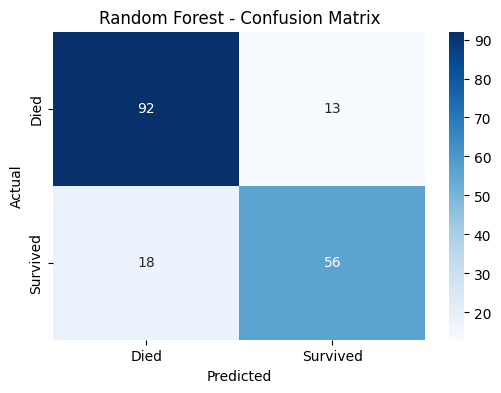


Classification Report:
              precision    recall  f1-score   support

        Died       0.84      0.88      0.86       105
    Survived       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, rf.predict(X_test),
      target_names=['Died', 'Survived']))

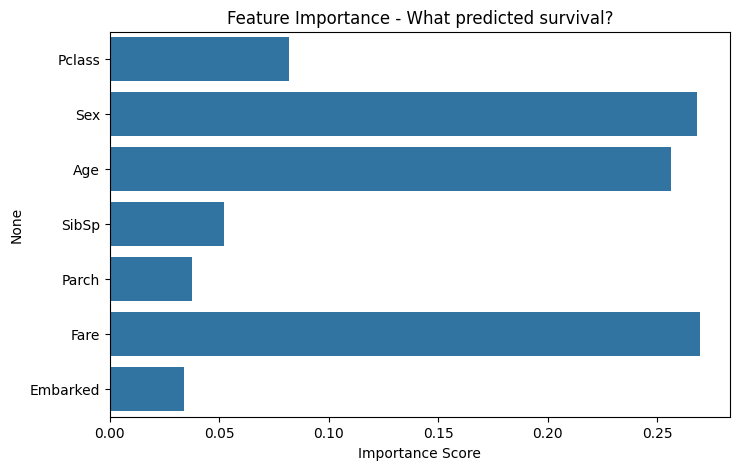

In [11]:
# Which features mattered most?
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance - What predicted survival?')
plt.xlabel('Importance Score')
plt.show()